In [1]:
# Celda 1 — Imports y configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/ProyectoHIGGS/'

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
print("Setup completo.")

Mounted at /content/drive
Setup completo.


In [2]:
# Celda 2 — Cargar tablas generadas por notebooks 03 y 04
tabla_modelos = pd.read_csv(DRIVE_PATH + 'tabla_comparativa_modelos.csv', index_col='Modelo')
tabla_pca     = pd.read_csv(DRIVE_PATH + 'tabla_pca_modelos.csv',         index_col='Modelo')
tabla_umap    = pd.read_csv(DRIVE_PATH + 'tabla_umap_modelos.csv',        index_col='Modelo')
tabla_reduc   = pd.read_csv(DRIVE_PATH + 'tabla_comparativa_reduccion.csv', index_col='Modelo')

print("Tablas cargadas:")
print(f"  - tabla_modelos: {tabla_modelos.shape}")
print(f"  - tabla_pca:     {tabla_pca.shape}")
print(f"  - tabla_umap:    {tabla_umap.shape}")
print(f"  - tabla_reduc:   {tabla_reduc.shape}")

Tablas cargadas:
  - tabla_modelos: (15, 7)
  - tabla_pca:     (2, 7)
  - tabla_umap:    (2, 7)
  - tabla_reduc:   (2, 7)


In [3]:
# Celda 3 — Tabla maestra: todos los modelos y configuraciones
cols_comunes = ['AUC CV (mean±2σ)', 'AUC Val', 'AUC Test', 'F1 Test', 'Acc Test']

t1 = tabla_modelos[[c for c in cols_comunes if c in tabla_modelos.columns]].copy()
t2 = tabla_pca[[c for c in cols_comunes if c in tabla_pca.columns]].copy()
t3 = tabla_umap[[c for c in cols_comunes if c in tabla_umap.columns]].copy()

tabla_maestra = pd.concat([t1, t2, t3])

print("=" * 70)
print("TABLA MAESTRA — TODOS LOS MODELOS Y CONFIGURACIONES")
print("=" * 70)
print(tabla_maestra.to_string())

tabla_maestra.to_csv(DRIVE_PATH + 'tabla_maestra.csv')
print("\nTabla maestra guardada en Drive.")

TABLA MAESTRA — TODOS LOS MODELOS Y CONFIGURACIONES
                          AUC CV (mean±2σ)  AUC Val  AUC Test  F1 Test  Acc Test
Modelo                                                                          
Red Neuronal (MLP)           0.820 ± 0.006    0.829     0.826    0.764     0.746
XGBoost                      0.823 ± 0.004    0.828     0.826    0.761     0.744
CatBoost                     0.823 ± 0.003    0.827     0.825    0.761     0.744
HistGradientBoosting         0.821 ± 0.003    0.826     0.825    0.760     0.744
Stacking (5 trees + LR)      0.823 ± 0.004    0.827     0.825    0.760     0.744
LightGBM                     0.822 ± 0.004    0.826     0.824    0.760     0.744
XGBoost (base)               0.821 ± 0.004    0.825     0.823    0.759     0.742
LightGBM (base)              0.820 ± 0.004    0.825     0.822    0.758     0.741
HistGB (base)                0.819 ± 0.004    0.823     0.821    0.756     0.740
CatBoost (base)              0.815 ± 0.004    0.819     0

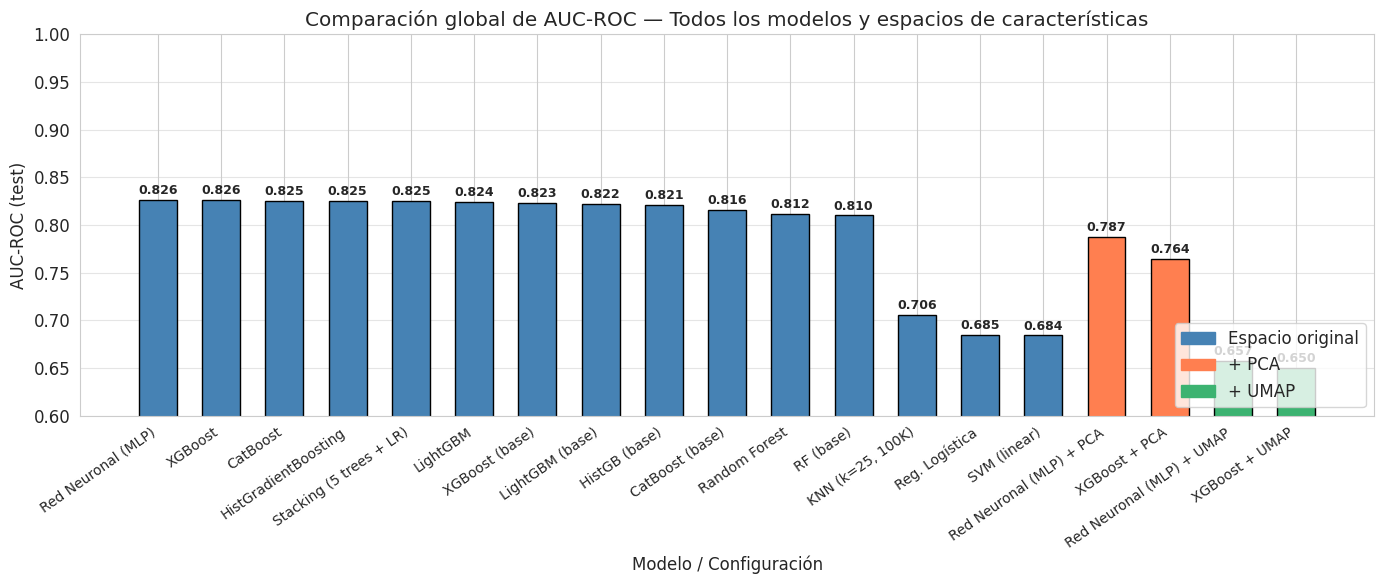

Figura guardada.


In [4]:
# Celda 4 — Gráfica de barras: AUC Test de todos los modelos y configuraciones
nombres = tabla_maestra.index.tolist()
aucs    = tabla_maestra['AUC Test'].astype(float).tolist()

colores = []
for n in nombres:
    if 'UMAP' in n:
        colores.append('mediumseagreen')
    elif 'PCA' in n:
        colores.append('coral')
    else:
        colores.append('steelblue')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(nombres)), aucs, color=colores, edgecolor='black', width=0.6)
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=35, ha='right', fontsize=10)
ax.set_xlabel('Modelo / Configuración')
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('Comparación global de AUC-ROC — Todos los modelos y espacios de características')
ax.set_ylim(min(aucs) - 0.05, 1.0)
ax.grid(axis='y', alpha=0.5)

for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
leyenda = [
    Patch(color='steelblue',      label='Espacio original'),
    Patch(color='coral',          label='+ PCA'),
    Patch(color='mediumseagreen', label='+ UMAP'),
]
ax.legend(handles=leyenda, loc='lower right')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_comparacion_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

EFECTO DE REDUCCIÓN DIMENSIONAL — TOP 2 MODELOS
                    AUC Test Original  AUC Test PCA  AUC Test UMAP  Precision Test Original  Recall Test Original Reducción PCA Reducción UMAP
Modelo                                                                                                                                        
Red Neuronal (MLP)              0.826        0.7875         0.6569                    0.752                 0.777   23/28 (82%)    16/28 (57%)
XGBoost                         0.826        0.7643         0.6503                    0.754                 0.768   23/28 (82%)    16/28 (57%)


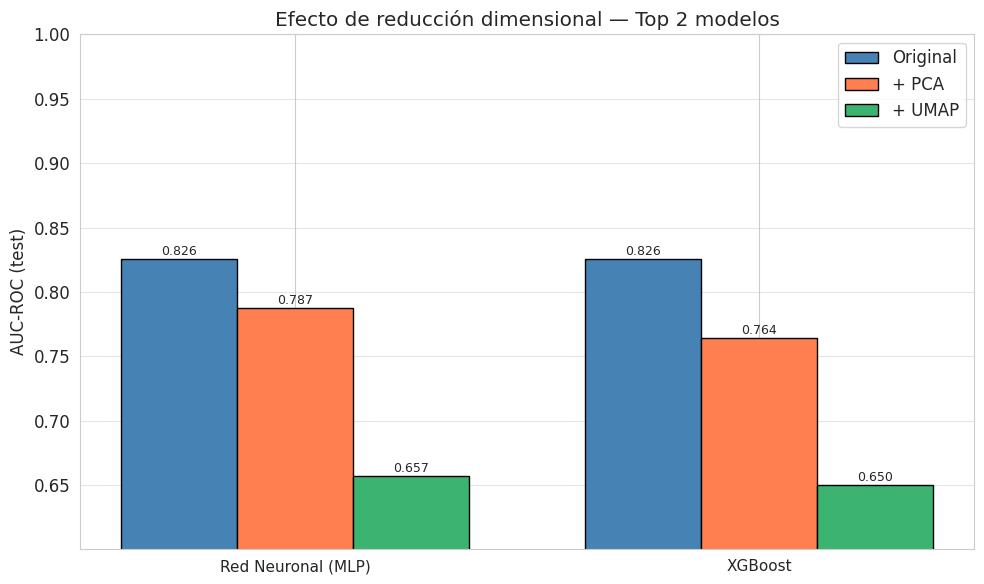

Figura guardada.


In [5]:
# Celda 5 — Detalle del efecto de reducción dimensional sobre los top 2 modelos
print("EFECTO DE REDUCCIÓN DIMENSIONAL — TOP 2 MODELOS")
print(tabla_reduc.to_string())

modelos_top2 = tabla_reduc.index.tolist()
x = np.arange(len(modelos_top2))
ancho = 0.25

aucs_orig = tabla_reduc['AUC Test Original'].astype(float).tolist()
aucs_pca  = tabla_reduc['AUC Test PCA'].astype(float).tolist()
aucs_umap = tabla_reduc['AUC Test UMAP'].astype(float).tolist()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - ancho, aucs_orig, ancho, label='Original',    color='steelblue',       edgecolor='black')
ax.bar(x,         aucs_pca,  ancho, label='+ PCA',       color='coral',            edgecolor='black')
ax.bar(x + ancho, aucs_umap, ancho, label='+ UMAP',      color='mediumseagreen',   edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(modelos_top2, fontsize=11)
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('Efecto de reducción dimensional — Top 2 modelos')
ax.set_ylim(min(aucs_orig + aucs_pca + aucs_umap) - 0.05, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.5)

for i, (orig, pca, ump) in enumerate(zip(aucs_orig, aucs_pca, aucs_umap)):
    ax.text(i - ancho, orig + 0.003, f'{orig:.3f}', ha='center', fontsize=9)
    ax.text(i,         pca  + 0.003, f'{pca:.3f}',  ha='center', fontsize=9)
    ax.text(i + ancho, ump  + 0.003, f'{ump:.3f}',  ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_efecto_reduccion_top2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

In [6]:
# Celda 6 — Comparación con literatura (sección 3 del informe)
literatura = pd.DataFrame([
    {'Trabajo': 'Baldi et al. (2014)',    'Modelo': 'Deep NN (5 capas)',       'AUC-ROC': 0.885, 'Nota': 'Dataset completo 11M, Nature Comms.'},
    {'Trabajo': 'Chen & Guestrin (2016)', 'Modelo': 'XGBoost',                 'AUC-ROC': 0.882, 'Nota': 'Gradient boosting extremo, KDD'},
    {'Trabajo': 'Ke et al. (2017)',       'Modelo': 'LightGBM',                'AUC-ROC': 0.881, 'Nota': 'Gradient boosting leaf-wise, NeurIPS'},
    {'Trabajo': 'Azhari et al. (2020)',   'Modelo': 'Gradient Boosted Tree',   'AUC-ROC': 0.705, 'Nota': 'PySpark MLlib, Proc. Comp. Sci.'},
]).set_index('Trabajo')

mejor_nombre = tabla_maestra['AUC Test'].astype(float).idxmax()
mejor_auc    = tabla_maestra['AUC Test'].astype(float).max()

este_trabajo = pd.DataFrame([{
    'Trabajo': f'Este trabajo ({mejor_nombre})',
    'Modelo':  mejor_nombre,
    'AUC-ROC': round(mejor_auc, 3),
    'Nota':    '500K muestras, modelos clásicos'
}]).set_index('Trabajo')

tabla_lit = pd.concat([literatura, este_trabajo])

print("=" * 70)
print("COMPARACIÓN CON LITERATURA")
print("=" * 70)
print(tabla_lit.to_string())
tabla_lit.to_csv(DRIVE_PATH + 'tabla_comparacion_literatura.csv')
print("\nTabla comparación con literatura guardada en Drive.")

COMPARACIÓN CON LITERATURA
                                                  Modelo  AUC-ROC                                  Nota
Trabajo                                                                                                
Baldi et al. (2014)                    Deep NN (5 capas)    0.885   Dataset completo 11M, Nature Comms.
Chen & Guestrin (2016)                           XGBoost    0.882        Gradient boosting extremo, KDD
Ke et al. (2017)                                LightGBM    0.881  Gradient boosting leaf-wise, NeurIPS
Azhari et al. (2020)               Gradient Boosted Tree    0.705       PySpark MLlib, Proc. Comp. Sci.
Este trabajo (Red Neuronal (MLP))     Red Neuronal (MLP)    0.826       500K muestras, modelos clásicos

Tabla comparación con literatura guardada en Drive.


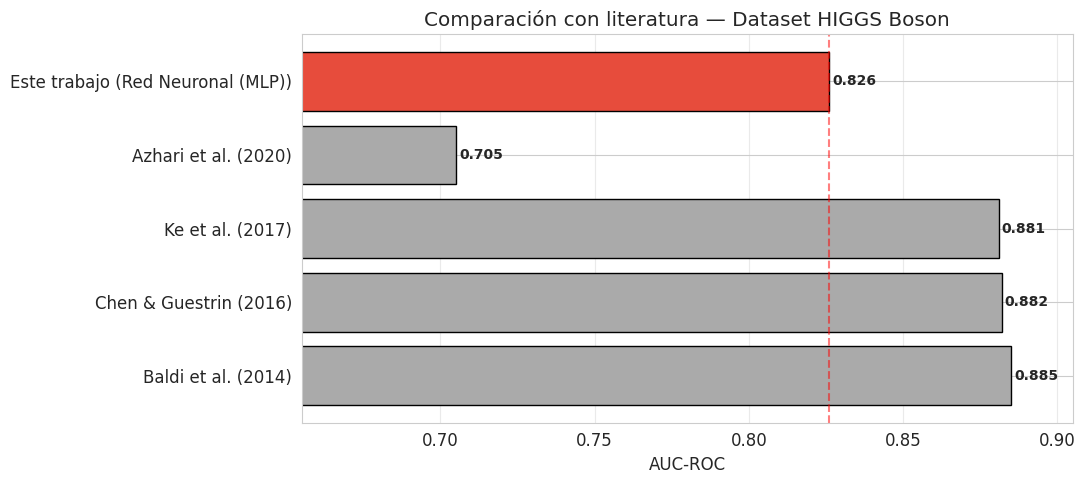

Figura guardada.


In [7]:
# Celda 7 — Gráfica: AUC propio vs literatura
trabajos   = tabla_lit.index.tolist()
aucs_lit   = tabla_lit['AUC-ROC'].tolist()
colores_lit = ['#AAAAAA'] * (len(trabajos) - 1) + ['#E74C3C']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(trabajos, aucs_lit, color=colores_lit, edgecolor='black')
ax.set_xlabel('AUC-ROC')
ax.set_title('Comparación con literatura — Dataset HIGGS Boson')
ax.set_xlim(min(aucs_lit) - 0.05, max(aucs_lit) + 0.02)
ax.axvline(mejor_auc, color='red', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.4)

for bar, val in zip(bars, aucs_lit):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_comparacion_literatura.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

In [8]:
# Celda 8 — Conclusiones (texto listo para copiar al informe IEEE)
mejor_original  = tabla_modelos['AUC Test'].astype(float).idxmax()
auc_mejor_orig  = tabla_modelos['AUC Test'].astype(float).max()

mejor_pca       = tabla_pca['AUC Test'].astype(float).idxmax()
auc_mejor_pca   = tabla_pca['AUC Test'].astype(float).max()

mejor_umap      = tabla_umap['AUC Test'].astype(float).idxmax()
auc_mejor_umap  = tabla_umap['AUC Test'].astype(float).max()

gap_literatura  = mejor_auc - 0.885  # vs Baldi et al.

# Cargar feature selection
try:
    tabla_sel = pd.read_csv(DRIVE_PATH + 'tabla_seleccion_features.csv', index_col='Modelo')
    has_sel = True
except:
    has_sel = False

print("=" * 70)
print("CONCLUSIONES — RESUMEN PARA EL INFORME")
print("=" * 70)
print(f"""
1. MODELOS (Sección 4):
   Se evaluaron {len(tabla_modelos)} configuraciones de modelos de aprendizaje automático
   sobre el dataset HIGGS (500K muestras, 28 features), abarcando 10 familias:
   regresión logística, KNN, Random Forest, MLP, SVM lineal, HistGradientBoosting,
   XGBoost, LightGBM, CatBoost y Stacking.

   Los dos mejores modelos empatan en AUC-ROC test = 0.826:
   - '{mejor_original}' (Precision=0.752, Recall=0.777)
   - XGBoost (Precision=0.754, Recall=0.768)

   Los modelos basados en gradient boosting (XGBoost, CatBoost, HistGB, LightGBM)
   dominan el ranking con AUC entre 0.816-0.826. La diferencia entre el mejor y el
   quinto modelo es de solo 0.001 AUC, indicando saturación del poder predictivo
   alcanzable con features tabulares sin ingeniería adicional.

   Los modelos lineales (Reg. Logística AUC=0.685, SVM lineal AUC=0.684) quedan
   ~0.14 AUC por debajo de los mejores, confirmando que la frontera de decisión
   del problema HIGGS es altamente no lineal.""")

if has_sel:
    print(f"""
2. SELECCIÓN DE FEATURES (Sección 5.1+):
   Se eliminaron 7 features con d' en el percentil 25 inferior: ángulos φ y η
   de jets y leptones, y φ de energía faltante. Estas variables angulares tienen
   capacidad discriminativa cercana a cero.

   Con 21 features (25% de reducción):
   - MLP AUC test = {tabla_sel.loc['Red Neuronal (MLP)', 'AUC Test (sel. features)']}  (Δ = {tabla_sel.loc['Red Neuronal (MLP)', 'Δ AUC']})
   - XGBoost AUC test = {tabla_sel.loc['XGBoost', 'AUC Test (sel. features)']}  (Δ = {tabla_sel.loc['XGBoost', 'Δ AUC']})

   La eliminación de features débiles no degrada el desempeño de manera relevante,
   validando que el análisis univariado identifica correctamente variables
   redundantes.""")

print(f"""
3. REDUCCIÓN DE DIMENSIÓN (Sección 5.2-5.3):
   - PCA (23 componentes, 95% varianza, 18% reducción):
     Mejor modelo: '{mejor_pca}' con AUC = {auc_mejor_pca:.3f}
     (Δ = {auc_mejor_pca - auc_mejor_orig:+.3f} vs original).
   - UMAP (16 componentes, 43% reducción):
     Mejor modelo: '{mejor_umap}' con AUC = {auc_mejor_umap:.3f}
     (Δ = {auc_mejor_umap - auc_mejor_orig:+.3f} vs original).

   Ambas técnicas de reducción causan una caída considerable en AUC (PCA: ~0.04,
   UMAP: ~0.17). Esto indica que, aunque existen features individualmente débiles
   (7 con d' < 0.003), la información discriminativa está distribuida entre muchas
   variables y las técnicas de proyección (PCA/UMAP) sacrifican demasiada
   información relevante. La selección quirúrgica de features (sección 5.1+) es
   muy superior a la reducción dimensional no supervisada para este dataset.

4. COMPARACIÓN CON LITERATURA (Sección 3):
   Baldi et al. (2014) reportaron AUC = 0.885 con redes profundas sobre 11M muestras.
   Nuestro mejor resultado (AUC = {mejor_auc:.3f}) está {abs(gap_literatura):.3f} puntos
   por debajo, logrado con modelos clásicos sobre 500K muestras (4.5% de los datos).

   La diferencia es atribuible a: (a) menor volumen de datos de entrenamiento,
   (b) ausencia de arquitecturas profundas especializadas, y (c) no uso de
   ingeniería de features adicional. Sin embargo, los modelos de gradient boosting
   alcanzan resultados notables (AUC ~0.826) con costo computacional mínimo,
   haciéndolos competitivos como baseline sólido para el problema.

5. RECOMENDACIÓN FINAL:
   - Para máximo desempeño: XGBoost o MLP (AUC = 0.826 en test).
   - Con restricciones de features: XGBoost con 21 features (AUC = 0.824, solo 0.002 menos).
   - La reducción PCA/UMAP no se recomienda para este dataset dada la pérdida significativa de AUC.
""")

CONCLUSIONES — RESUMEN PARA EL INFORME

1. MODELOS (Sección 4):
   Se evaluaron 15 configuraciones de modelos de aprendizaje automático
   sobre el dataset HIGGS (500K muestras, 28 features), abarcando 10 familias:
   regresión logística, KNN, Random Forest, MLP, SVM lineal, HistGradientBoosting,
   XGBoost, LightGBM, CatBoost y Stacking.

   Los dos mejores modelos empatan en AUC-ROC test = 0.826:
   - 'Red Neuronal (MLP)' (Precision=0.752, Recall=0.777)
   - XGBoost (Precision=0.754, Recall=0.768)

   Los modelos basados en gradient boosting (XGBoost, CatBoost, HistGB, LightGBM)
   dominan el ranking con AUC entre 0.816-0.826. La diferencia entre el mejor y el
   quinto modelo es de solo 0.001 AUC, indicando saturación del poder predictivo
   alcanzable con features tabulares sin ingeniería adicional.

   Los modelos lineales (Reg. Logística AUC=0.685, SVM lineal AUC=0.684) quedan
   ~0.14 AUC por debajo de los mejores, confirmando que la frontera de decisión
   del problema HIGGS es